<a href="https://colab.research.google.com/github/franguibaud/Control-de-sueldo/blob/main/Copia_de_TrabajoN1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
archivo= pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv')

In [ ]:
archivo.shape


(768, 9)

In [ ]:
archivo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


#Las columnas no tienen el tipo de dato que esperaba ya que en el pdf del Trabajo practico me marcaba que habia 6 datos del tipo FLOAT, 1 dato del tipo INT y 1 dato del tipo binario.

In [ ]:
archivo.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#Lo que me llama la atencion es que hay variables con minimos en 0, y eso en casos como la glucosa o BMI no es posible asi que lo tomamos como valores faltantes.

In [ ]:
archivo["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


In [ ]:
archivo["Outcome"].value_counts(normalize=True)

,proportion
Outcome,
0,0.651042
1,0.348958


array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

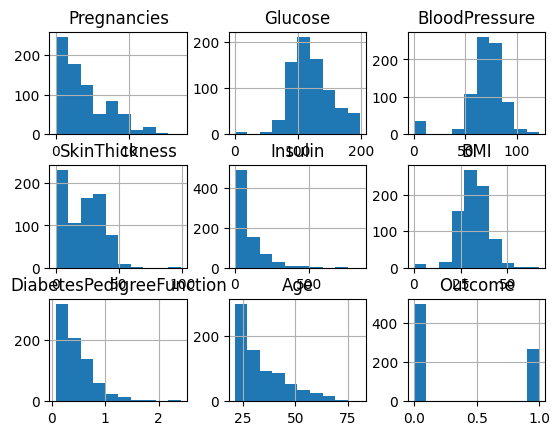

In [ ]:
archivo.hist()

Las variables como la insulina, la edad, embarazos, Grosor del pliegue cutáneo del tríceps (mm), y la funcion de historial familiar de diabetes, tienen un claro sesgo positivo, donde la mayor parte de los datos se encuentran en valores bajos como por ejemplo: la edad, esto quiere decir que las mujeres a la que se le hicieron estos estudios tienden a ser mas jovenes.

la variable outcome quiere decir que puede ser una u otra, 1= diabetes, 0= sin diabetes. Lo que quiere decir que hay mayor numero de mujeres que no tienen diabetes.

las demas variables tienen valores centrados, mas simetricos entre si. Como por ejemplo el BMI, quiere decir que la masa corporal de la mayoria de mujeres ronda entre los mismos valores.






In [ ]:
archivo.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


Todas las variables menos edad, outcome, y pregnancies deberian ser float ya que tienen valores cuantitativos continuos. Outcome deberia ser cualitativo ordinal. Edad en realidad esta bien que sea del tipo float ya que la edad esta basada en el tiempo y el tiempo es del tipo continuo. Pregnancies esta bien, es una variable del tipo int, ya que cuenta la cantidad de embarazos.

In [ ]:
archivo['Outcome'] = archivo['Outcome'].astype('category')


La variable al tratarse como numerica, puede llegar a ser mas facil aprovechar la información completa de la cantidad de embarazos y detectar si existe alguna relación con la presencia de diabetes. Es una forma simple y directa de trabajar con la variable. La desventaja es que algunos modelos podrían asumir que tener mas embarazos es siempre proporcional a cambiar el riesgo de tener diabetes, lo cual no puede llegar a ocurrir en la realidad.

La variable al tratarse como categorica, se puede diferenciar grupos sin que tengan una relación entre los valores. Esto podría ser útil si ciertos rangos de embarazos se comportan de manera distinta. Como desventaja, se pierde información numérica y del orden de la variable.

Lo que yo haria es tratarla como numérica, porque es una cantidad y tiene orden.
Solo la haría categórica si quisiera agrupar embarazos en rangos para analizar cosas específicas.

Pero en realidad la decisión depende del modelo y del comportamiento en el análisis exploratorio.

In [ ]:
archivo.nunique()

,0
Pregnancies,17
Glucose,136
BloodPressure,47
SkinThickness,51
Insulin,186
BMI,248
DiabetesPedigreeFunction,517
Age,52
Outcome,2


Mayor: glucose, insulin, DiabetesPedigreeFunction, BMI

Menor: outcome, Pregnancies

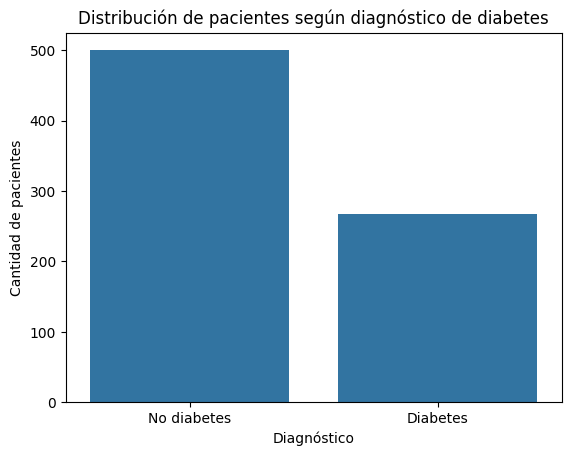

In [ ]:
sns.countplot(data=archivo, x='Outcome')

plt.title("Distribución de pacientes según diagnóstico de diabetes")
plt.xlabel("Diagnóstico")
plt.ylabel("Cantidad de pacientes")
plt.xticks([0, 1], ["No diabetes", "Diabetes"])

plt.show()


In [ ]:
(archivo['Glucose'] == 0).sum()

np.int64(5)

In [ ]:
(archivo['BloodPressure'] == 0).sum()

np.int64(35)

In [ ]:
(archivo['SkinThickness'] == 0).sum()

np.int64(227)

In [ ]:
(archivo['Insulin'] == 0).sum()

np.int64(374)

In [ ]:
(archivo['BMI'] == 0).sum()

np.int64(11)

In [ ]:
columnas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columnas:
    porcentaje = (archivo[col] == 0).mean() * 100
    print(f"{col}: {porcentaje:.2f}%")


Glucose: 0.65%
BloodPressure: 4.56%
SkinThickness: 29.56%
Insulin: 48.70%
BMI: 1.43%


In [ ]:
archivo['Glucose'] = archivo['Glucose'].replace(0, np.nan)

In [ ]:
archivo['BloodPressure'] = archivo['BloodPressure'].replace(0, np.nan)

In [ ]:
archivo['SkinThickness'] = archivo['SkinThickness'].replace(0, np.nan)

In [ ]:
archivo['Insulin'] = archivo['Insulin'].replace(0, np.nan)

In [ ]:
archivo['BMI'] = archivo['BMI'].replace(0, np.nan)

In [ ]:
archivo.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


<Axes: >

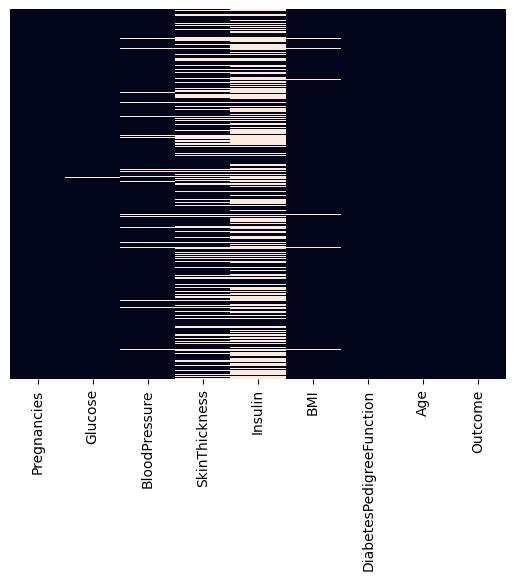

In [ ]:
sns.heatmap(archivo.isnull(), cbar=False, yticklabels=False)

El heatmap visualiza claramente los valores nulos, especialmente en las columnas 'Insulin' y 'SkinThickness'.



In [ ]:
archivo["Insulin_faltante"] = archivo["Insulin"].isna()
archivo["SkinThickness_faltante"] = archivo["SkinThickness"].isna()

corr_faltantes = archivo["Insulin_faltante"].corr(archivo["SkinThickness_faltante"])
print("Correlación entre faltantes:", corr_faltantes)

Correlación entre faltantes: 0.6648544897063741


In [ ]:
tabla = pd.crosstab(archivo["Insulin"].isna(), archivo["SkinThickness"].isna())
print(tabla)

SkinThickness  False  True 
Insulin                    
False            394      0
True             147    227


Si, si faltan valores en una variable tiende a faltar valores en la otra.



In [ ]:
archivo['Glucose'] = archivo['Glucose'].fillna(archivo['Glucose'].median())
archivo['BloodPressure'] = archivo['BloodPressure'].fillna(archivo['BloodPressure'].median())

Es conveniente reemplazar los valores faltantes por la mediana ya que esta medida no se ve afectada por los outliers, en cambio la media por ejemplo si y ya tiene valores mas dispersos.

In [ ]:
archivo['Insulin'] = archivo['Insulin'].fillna(
    archivo.groupby('Outcome', observed=False)['Insulin'].transform('median')
)

archivo['SkinThickness'] = archivo['SkinThickness'].fillna(
    archivo.groupby('Outcome', observed=False)['SkinThickness'].transform('median')
)

In [ ]:
Q1_dpf = archivo['DiabetesPedigreeFunction'].quantile(0.25)
Q3_dpf = archivo['DiabetesPedigreeFunction'].quantile(0.75)

IQR_dpf = Q3_dpf - Q1_dpf

limite_inferior_dpf = Q1_dpf - 1.5 * IQR_dpf
limite_superior_dpf = Q3_dpf + 1.5 * IQR_dpf

# Guardar una copia de la columna antes del capping para comparación
dpf_before_capping = archivo['DiabetesPedigreeFunction'].copy()

# Aplicar capping a DiabetesPedigreeFunction
archivo['DiabetesPedigreeFunction'] = archivo['DiabetesPedigreeFunction'].clip(lower=limite_inferior_dpf, upper=limite_superior_dpf)

dpf_after_capping = archivo['DiabetesPedigreeFunction'].copy()

print("Q1 (DiabetesPedigreeFunction):", Q1_dpf)
print("Q3 (DiabetesPedigreeFunction):", Q3_dpf)
print("IQR (DiabetesPedigreeFunction):", IQR_dpf)
print("Límite inferior (DiabetesPedigreeFunction):", limite_inferior_dpf)
print("Límite superior (DiabetesPedigreeFunction):", limite_superior_dpf)
print("Valor mínimo después del capping:", archivo['DiabetesPedigreeFunction'].min())
print("Valor máximo después del capping:", archivo['DiabetesPedigreeFunction'].max())

Q1 (DiabetesPedigreeFunction): 0.24375
Q3 (DiabetesPedigreeFunction): 0.62625
IQR (DiabetesPedigreeFunction): 0.38249999999999995
Límite inferior (DiabetesPedigreeFunction): -0.32999999999999996
Límite superior (DiabetesPedigreeFunction): 1.2
Valor mínimo después del capping: 0.078
Valor máximo después del capping: 1.2


In [ ]:
archivo.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0
Insulin_faltante,0


Aca me di cuenta que BMI seguia con valores faltantes asi que voy a corregirlo.

In [ ]:
archivo['BMI'] = archivo['BMI'].replace(0, np.nan)

In [ ]:
archivo['BMI'] = archivo['BMI'].fillna(archivo['BMI'].median())

In [ ]:
archivo.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0
Insulin_faltante,0


Cambie los valores faltantes por la mediana para tener los valores bien ordenados y que no se dejen llevar por los outliers.

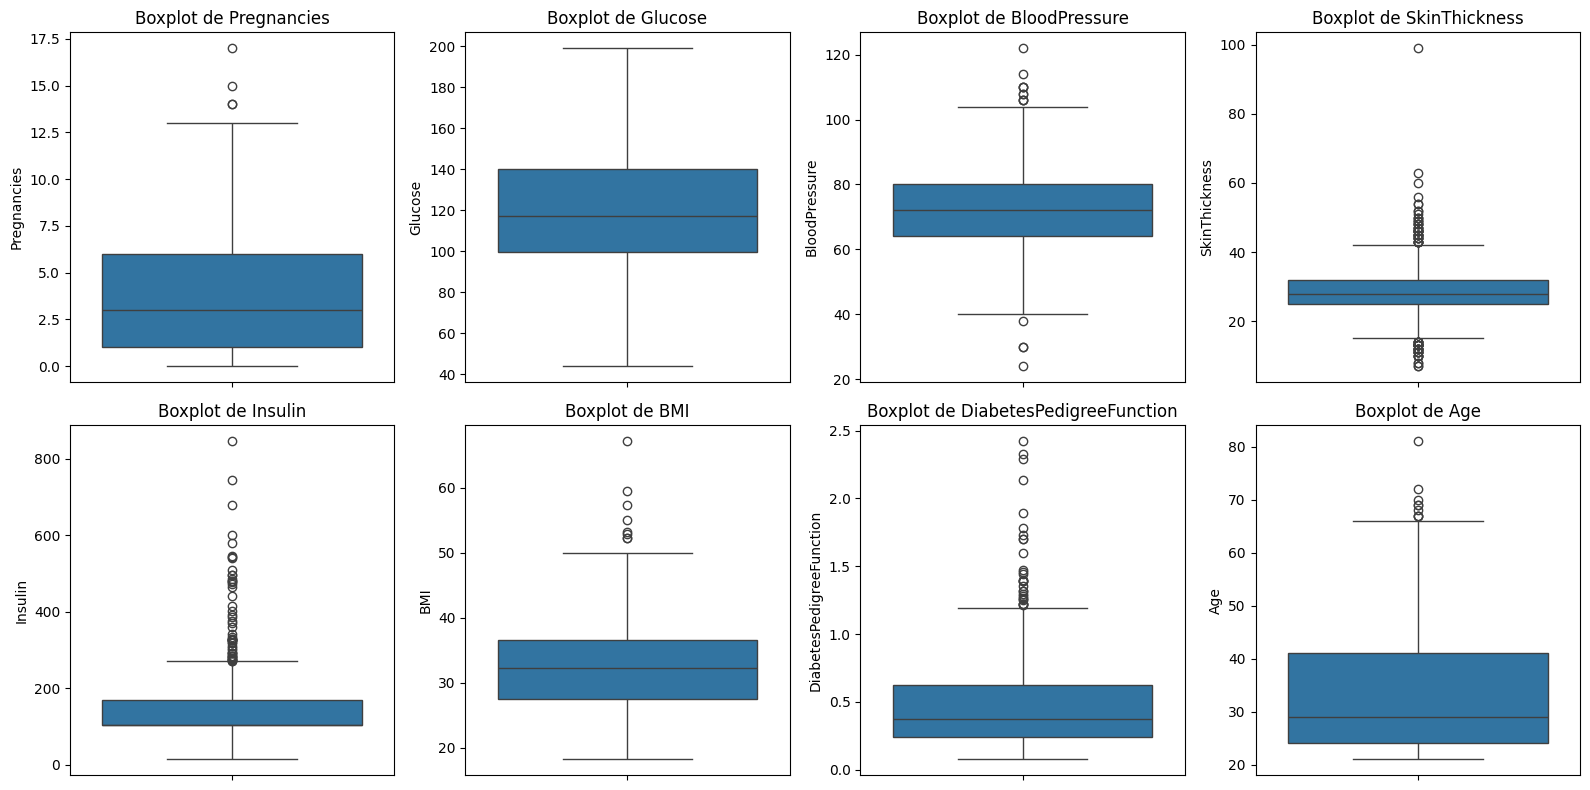

In [ ]:


# Tomar todas las columnas numéricas
columnas_numericas = archivo.select_dtypes(include='number').columns.tolist()

# Sacar Outcome si está
if 'Outcome' in columnas_numericas:
    columnas_numericas.remove('Outcome')

# Crear grilla dinámica según la cantidad de variables
n = len(columnas_numericas)
filas = 2
columnas = 4

fig, axes = plt.subplots(filas, columnas, figsize=(16, 8))
axes = axes.flatten()

# Graficar boxplots
for i, col in enumerate(columnas_numericas):
    sns.boxplot(y=archivo[col], ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel(col)

# Borrar subplots vacíos si sobran
for j in range(len(columnas_numericas), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Por lo que observo se ven bastantes outliers en las variables insulin, DiabetesPedigreeFunction, SkinThicknes, Age, y BMI.  

insulin muestra una gram dispersion de los datos y una cola muy larga a los valores superiores. Se puede decir que tiene un sesgo negativo, esto indica que hay numerosos outliers con niveles de insulina extremadamente altos en comparacion con la mayoria de la poblacion.

DiabetesPedigreeFunction tambien presenta una cola extendida hacia los valores más altos, esto quiere decir que hay un número considerable de individuos con un historial familiar de diabetes. Estos valores atípicos pueden ser importantes para identificar patrones de riesgo.

SkinThickness presenta una cola extendida hacia valores altos y una cola extendida hacia valores mas bajos, estos valores atipicos pueden ser relevantes ya que indican desviaciones de la media que pueden llegar a estar relacionadas con condiciones de salud o caracteristicas especificas en el contexto de la diabetes.

In [ ]:

Q1 = archivo['Insulin'].quantile(0.25)
Q3 = archivo['Insulin'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_insulin = archivo[
    (archivo['Insulin'] < limite_inferior) | (archivo['Insulin'] > limite_superior)
]

cantidad_outliers = outliers_insulin.shape[0]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Cantidad de outliers en Insulin:", cantidad_outliers)

Q1: 102.5
Q3: 169.5
IQR: 67.0
Límite inferior: 2.0
Límite superior: 270.0
Cantidad de outliers en Insulin: 51


In [ ]:
columnas_numericas = archivo.select_dtypes(include='number').columns.tolist()

if 'Outcome' in columnas_numericas:
    columnas_numericas.remove('Outcome')

resumen_outliers = []

for col in columnas_numericas:
    Q1 = archivo[col].quantile(0.25)
    Q3 = archivo[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    cantidad_outliers = ((archivo[col] < limite_inferior) | (archivo[col] > limite_superior)).sum()

    resumen_outliers.append({
        'Variable': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Límite inferior': limite_inferior,
        'Límite superior': limite_superior,
        'Cantidad de outliers': cantidad_outliers
    })

resumen_outliers = pd.DataFrame(resumen_outliers)

resumen_outliers

,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Cantidad de outliers
0,Pregnancies,1.00000,6.00000,5.0000,-6.50,13.50,4
1,Glucose,99.75000,140.25000,40.5000,39.00,201.00,0
2,BloodPressure,64.00000,80.00000,16.0000,40.00,104.00,14
3,SkinThickness,25.00000,32.00000,7.0000,14.50,42.50,87
4,Insulin,102.50000,169.50000,67.0000,2.00,270.00,51
5,BMI,27.50000,36.60000,9.1000,13.85,50.25,8
6,DiabetesPedigreeFunction,0.24375,0.62625,0.3825,-0.33,1.20,29
7,Age,24.00000,41.00000,17.0000,-1.50,66.50,9


In [ ]:
archivo['Z_BMI'] = (archivo['BMI'] - archivo['BMI'].mean()) / archivo['BMI'].std()

outliers_bmi = archivo[abs(archivo['Z_BMI']) > 3]

cantidad_outliers_bmi = outliers_bmi.shape[0]

print("Cantidad de outliers extremos en BMI:", cantidad_outliers_bmi)

outliers_bmi[['BMI', 'Z_BMI']]

Cantidad de outliers extremos en BMI: 5


,BMI,Z_BMI
120,53.2,3.017347
125,55.0,3.279158
177,67.1,5.039113
445,59.4,3.919142
673,57.3,3.613695


El metodo de IQR detecta mas outliers pero el metodo de z-score detecta los valores mas extremos, yo creo que es depende lo que quieras buscar pero me quedo con el metodo de iqr que ademas es mas facil de implementar a mi gusto.

In [ ]:
Q1 = archivo['Insulin'].quantile(0.25)
Q3 = archivo['Insulin'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

insulin_before_capping = archivo['Insulin'].copy()

archivo['Insulin'] = archivo['Insulin'].clip(lower=limite_inferior, upper=limite_superior)

insulin_after_capping = archivo['Insulin'].copy()

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Valor mínimo después del capping:", archivo['Insulin'].min())
print("Valor máximo después del capping:", archivo['Insulin'].max())

Q1: 102.5
Q3: 169.5
IQR: 67.0
Límite inferior: 2.0
Límite superior: 270.0
Valor mínimo después del capping: 14.0
Valor máximo después del capping: 270.0


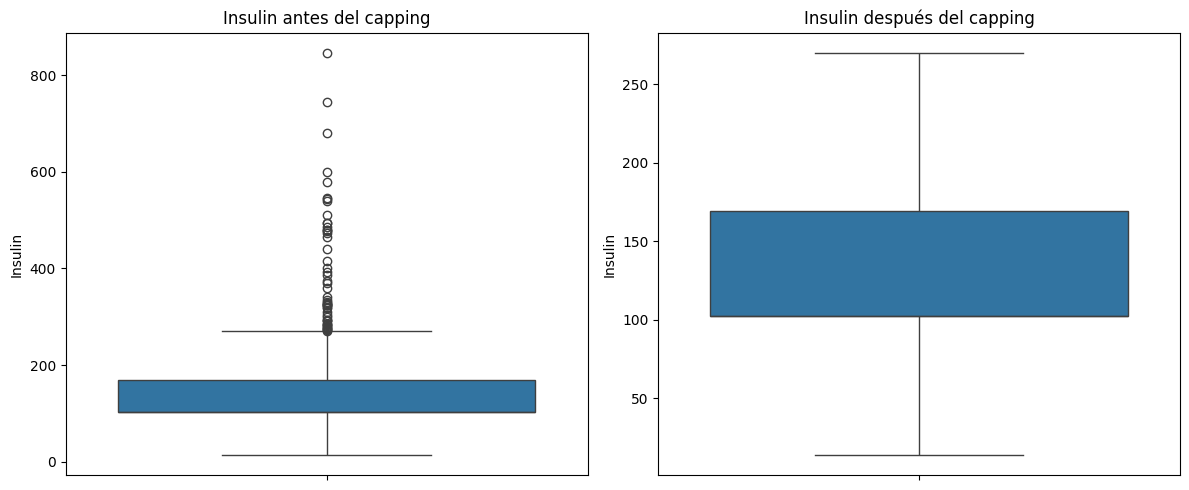

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=insulin_before_capping, ax=axes[0])
axes[0].set_title('Insulin antes del capping')
axes[0].set_ylabel('Insulin')

sns.boxplot(y=insulin_after_capping, ax=axes[1])
axes[1].set_title('Insulin después del capping')
axes[1].set_ylabel('Insulin')

plt.tight_layout()
plt.show()

Para mi parecer una opcion seria no eliminarlos por que pueden llegar a ser valores reales, pero como me piden que aplique una tecnica, elegi optar por la técnica de capping para manejar sus outliers, de manera similar a como lo hice con la variable Insulin. Esto ayuda a limitar el impacto de los valores extremos sin eliminarlos por completo. Esto permite que los modelos trabajen con una representación más 'estable' del riesgo genético de diabetes.

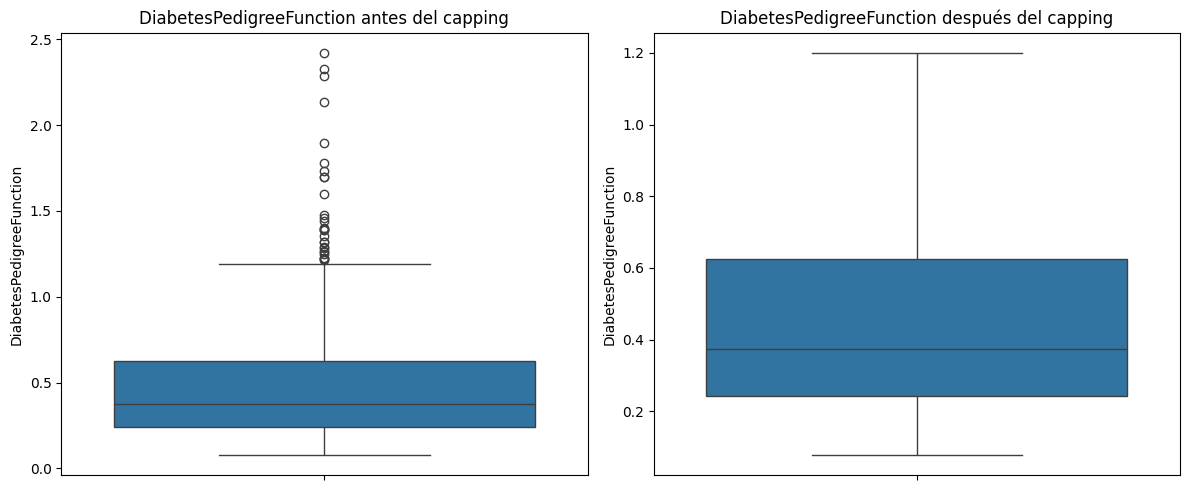

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(y=dpf_before_capping, ax=axes[0])
axes[0].set_title('DiabetesPedigreeFunction antes del capping')
axes[0].set_ylabel('DiabetesPedigreeFunction')

sns.boxplot(y=dpf_after_capping, ax=axes[1])
axes[1].set_title('DiabetesPedigreeFunction después del capping')
axes[1].set_ylabel('DiabetesPedigreeFunction')

plt.tight_layout()
plt.show()

In [ ]:
columnas_numericas = archivo.select_dtypes(include='number').columns.tolist()

if 'Outcome' in columnas_numericas:
    columnas_numericas.remove('Outcome')

archivo[columnas_numericas].describe().loc[['mean', 'std', 'min', 'max']]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Z_BMI
mean,3.845052,121.656250,72.386719,29.089844,133.085938,32.455208,0.458914,33.240885,2.544261e-16
std,3.369578,30.438286,12.096642,8.890820,58.124185,6.875177,0.285596,11.760232,1.000000e+00
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,-2.073432e+00
max,17.000000,199.000000,122.000000,99.000000,270.000000,67.100000,1.200000,81.000000,5.039113e+00


In [ ]:
df_features = archivo.select_dtypes(include='number').drop(columns='Outcome', errors='ignore')

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Crear y aplicar Min-Max Scaler
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(
    scaler.fit_transform(df_features),
    columns=df_features.columns
)

# Verificar que los valores estén entre 0 y 1
print(df_normalized.min())
print(df_normalized.max())

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Z_BMI                       0.0
dtype: float64
Pregnancies                 1.0
Glucose                     1.0
BloodPressure               1.0
SkinThickness               1.0
Insulin                     1.0
BMI                         1.0
DiabetesPedigreeFunction    1.0
Age                         1.0
Z_BMI                       1.0
dtype: float64


In [ ]:
df_normalized.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Z_BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,0.226180,0.501008,0.493742,0.240107,0.465179,0.291518,0.339496,0.204015,0.291518
std,0.198210,0.196376,0.123435,0.096639,0.227048,0.140597,0.254542,0.196004,0.140597
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.058824,0.359677,0.408163,0.195652,0.345703,0.190184,0.147727,0.050000,0.190184
50%,0.176471,0.470968,0.489796,0.228261,0.345703,0.288344,0.262478,0.133333,0.288344
75%,0.352941,0.620968,0.571429,0.271739,0.607422,0.376278,0.488636,0.333333,0.376278
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


los valores minimos y maximos son 0 y 1.


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = pd.DataFrame(
    scaler.fit_transform(df_features),
    columns=df_features.columns
)

print(df_standardized.mean())
print(df_standardized.std())

Pregnancies                -6.476301e-17
Glucose                     4.625929e-18
BloodPressure               5.782412e-18
SkinThickness               8.095376e-18
Insulin                     0.000000e+00
BMI                         2.613650e-16
DiabetesPedigreeFunction   -2.081668e-16
Age                         1.931325e-16
Z_BMI                       6.938894e-18
dtype: float64
Pregnancies                 1.000652
Glucose                     1.000652
BloodPressure               1.000652
SkinThickness               1.000652
Insulin                     1.000652
BMI                         1.000652
DiabetesPedigreeFunction    1.000652
Age                         1.000652
Z_BMI                       1.000652
dtype: float64


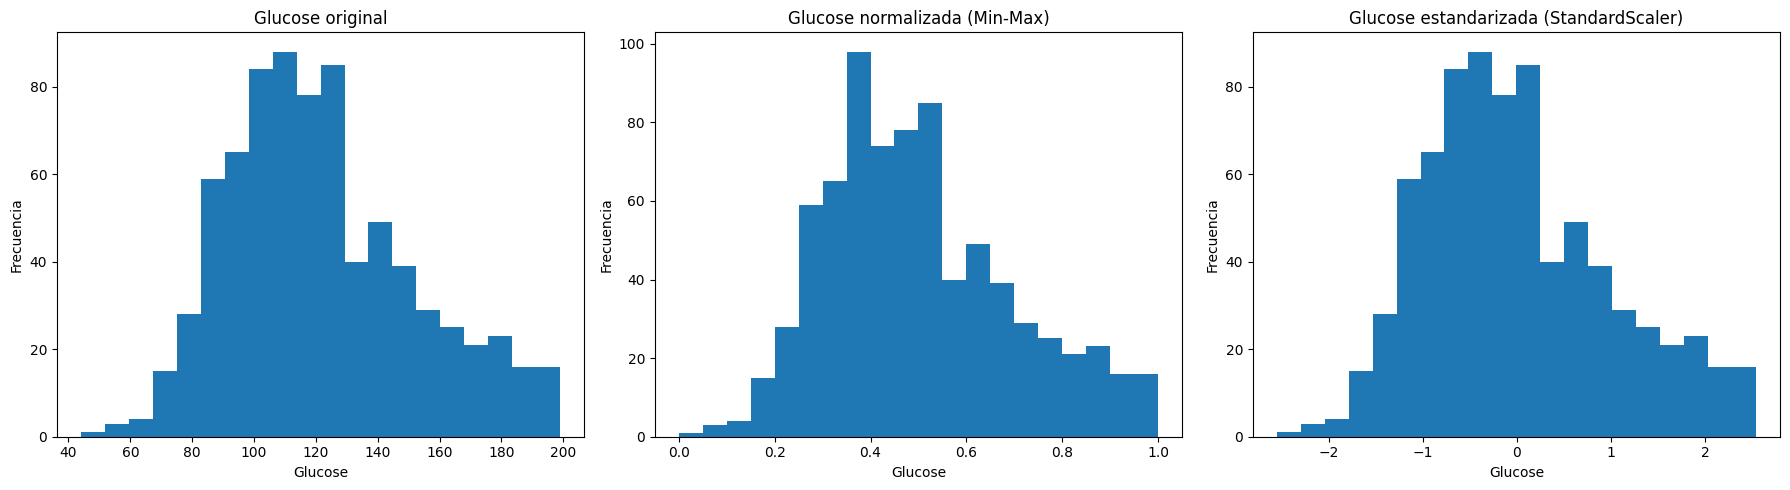

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Antes del escalado
axes[0].hist(archivo['Glucose'], bins=20)
axes[0].set_title('Glucose original')
axes[0].set_xlabel('Glucose')
axes[0].set_ylabel('Frecuencia')

# (b) Después de Min-Max
axes[1].hist(df_normalized['Glucose'], bins=20)
axes[1].set_title('Glucose normalizada (Min-Max)')
axes[1].set_xlabel('Glucose')
axes[1].set_ylabel('Frecuencia')

# (c) Después de estandarización
axes[2].hist(df_standardized['Glucose'], bins=20)
axes[2].set_title('Glucose estandarizada (StandardScaler)')
axes[2].set_xlabel('Glucose')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Usaría Min-Max cuando quiero llevar todo de 0 a 1 y no hay outliers fuertes.
Usaría estandarización cuando las variables tienen escalas muy distintas y el modelo trabaja mejor con datos centrados, pero tampoco es ideal si hay outliers fuertes.

In [ ]:

df_final = pd.concat([df_standardized, archivo['Outcome']], axis=1)

print(df_final.head())

df_final.to_csv('diabetes_preprocesado.csv', index=False)

   Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
0     0.639947  0.866045      -0.031990       0.665181  0.626896  0.166619   
1    -0.844885 -1.205066      -0.528319      -0.010112 -0.526560 -0.852200   
2     1.233880  2.016662      -0.693761       0.327535  0.626896 -1.332500   
3    -0.844885 -1.073567      -0.528319      -0.685405 -0.672894 -0.633881   
4    -1.141852  0.504422      -2.679076       0.665181  0.601072  1.549303   

   DiabetesPedigreeFunction       Age     Z_BMI Outcome  
0                  0.588927  1.425995  0.166619       1  
1                 -0.378101 -0.190672 -0.852200       0  
2                  0.746595 -0.105584 -1.332500       1  
3                 -1.022787 -1.041549 -0.633881       0  
4                  2.596563 -0.020496  1.549303       1  


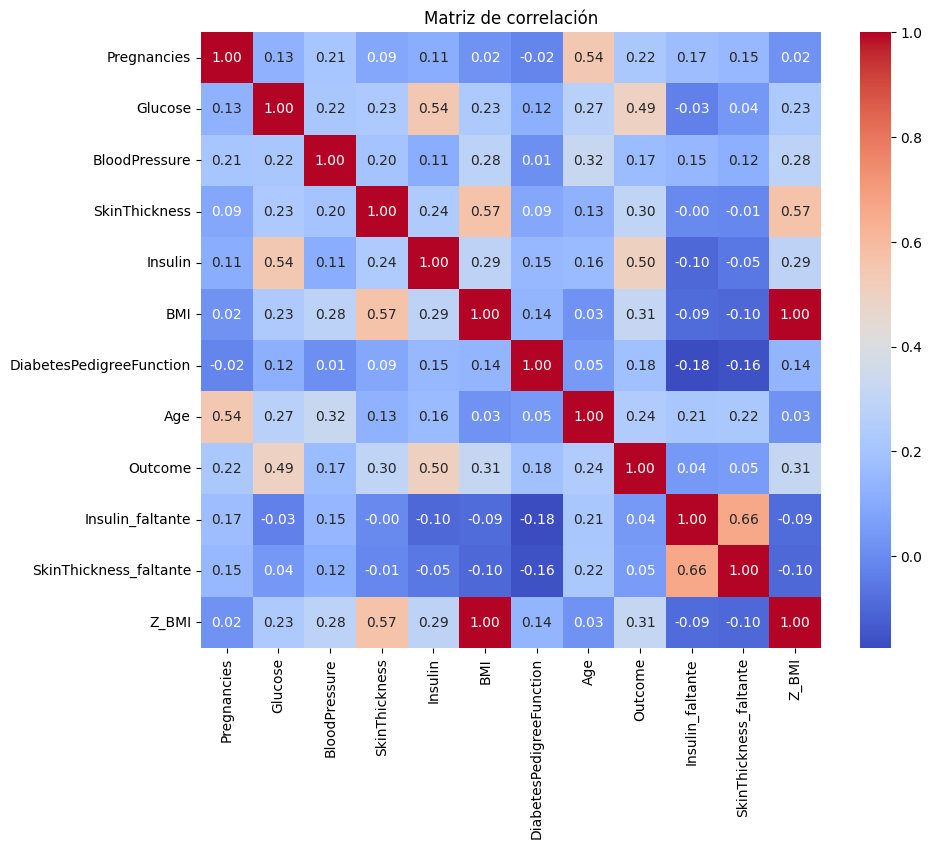

Outcome                     1.000000
Insulin                     0.500678
Glucose                     0.492782
Z_BMI                       0.312038
BMI                         0.312038
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.184969
BloodPressure               0.165723
SkinThickness_faltante      0.052603
Insulin_faltante            0.040934
Name: Outcome, dtype: float64


In [ ]:
archivo['Outcome'] = pd.to_numeric(archivo['Outcome'])

corr_matrix = archivo.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

print(corr_matrix['Outcome'].sort_values(ascending=False))

Las variables que tienen mayor correlacion con Outcome son Glucose e Insuline, son las variables que mas se relacionan al saber si tengo diabetes o no.